# Run 1: Cosmic-Ray Model with Height Grid

This notebook builds the HDF5 primary cosmic-ray model used by the rest of the CORSIKA pipeline.

The stored distribution includes primary species, energy, zenith angle, azimuth, and observation height:

$$
P(s,E,\theta,\phi,h)=P(s,E)P(\theta)P(\phi)P(h).
$$

CRFlux models do not depend on atmospheric height, so the physical species-energy flux table is duplicated across the height grid through a uniform $P(h)$. This lets later steps sample CORSIKA campaigns at several observation levels and build flux tensors in $E_\nu$, $\theta_\nu$, and $h$.

## 1. Libraries

This section imports the scientific Python stack, enables inline Matplotlib rendering, and checks that the CRFlux package is available before any model construction is attempted.

In [1]:
from __future__ import annotations
%matplotlib inline

from typing import Any, Callable
from dataclasses import dataclass, replace

from pathlib import Path
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np

try:
    import crflux.models as crf
    CRFLUX_AVAILABLE = True
except ImportError:
    crf = None
    CRFLUX_AVAILABLE = False

plt.style.use("seaborn-v0_8-whitegrid")

# Section 1 smoke test: verify that the scientific stack was imported.
print(f"NumPy version: {np.__version__}")
print(f"h5py version: {h5py.__version__}")
print(f"CRFlux available: {CRFLUX_AVAILABLE}")
assert np.__version__
assert h5py.__version__
assert plt is not None

# Section 1 diagnostic: report imported plotting backend and optional CRFlux availability.
print(f"\nMatplotlib inline rendering is enabled in notebooks.")
print(f"CRFlux available: {CRFLUX_AVAILABLE}")
print(f"Configured style: seaborn-v0_8-whitegrid")

print("\nSection 1 test passed: libraries are available.")


NumPy version: 2.4.5
h5py version: 3.16.0
CRFlux available: True

Matplotlib inline rendering is enabled in notebooks.
CRFlux available: True
Configured style: seaborn-v0_8-whitegrid

Section 1 test passed: libraries are available.


## 2. Parameters

This section defines shared filesystem paths and the physical grid configuration used to build the primary cosmic-ray model. The grid covers primary species, energy, arrival direction, and observation height.

- Energies are expressed in GeV
- Angular limits in degrees
- Particle identifiers follow the CORSIKA convention used by CRFlux: proton is `14`, while nuclei are represented as `100 * A + Z`.

### 2.1. Paths

In [2]:
PATH_CORSIKA_ROOT = "/home/juan/hep/opt/corsika8-install"
RUN = "run_test"

DEFAULT_OUTPUT_ROOT = Path(r"/mnt/v/output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))
OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_CORSIKA_ROOT = Path(OUTPUT_DATA_ROOT / "corsika")
OUTPUT_CORSIKA_ROOT.mkdir(parents=True, exist_ok=True)

# Backward-compatible aliases used by the original notebook code.
PATH_OUTPUT_ROOT = OUTPUT_ROOT
PATH_OUTPUT_CORSIKA = OUTPUT_CORSIKA_ROOT
PATH_OUTPUT_CORSIKA_GENERATOR = Path(OUTPUT_CORSIKA_ROOT / "generator")
PATH_OUTPUT_CORSIKA_GENERATOR.mkdir(parents=True, exist_ok=True)

PATH_OUTPUT_RUN = Path(PATH_OUTPUT_CORSIKA_GENERATOR / RUN)
PATH_CRMODEL_FILE = Path(PATH_OUTPUT_RUN / "cosmic_ray_model_test.h5")
PATH_PRIMARIES_FILE = Path(PATH_OUTPUT_RUN / "primaries_test.csv")
PATH_MANIFEST_FILE = Path(PATH_OUTPUT_RUN / "manifest.csv")
PATH_DATASET_NEUTRINO_FILE = Path(PATH_OUTPUT_RUN / "dataset_neutrino_test.h5")
PATH_OUTPUT_RUN.mkdir(parents=True, exist_ok=True)

print(" Configured workflow paths:\n", "=" * 80)
print(" - PATH_CORSIKA_ROOT = ", PATH_CORSIKA_ROOT)
print(" - DEFAULT_OUTPUT_ROOT = ", DEFAULT_OUTPUT_ROOT)
print(" - OUTPUT_ROOT = ", OUTPUT_ROOT)
print(" - OUTPUT_DATA_ROOT = ", OUTPUT_DATA_ROOT)
print(" - OUTPUT_CORSIKA_ROOT = ", OUTPUT_CORSIKA_ROOT)
print(" - RUN = ", RUN, "\n")

print(" Output paths:\n", "=" * 80)
print(" - PATH_OUTPUT_RUN       = ", PATH_OUTPUT_RUN)
print(" - PATH_CRMODEL_FILE     = ", PATH_CRMODEL_FILE)
print(" - PATH_PRIMARIES_FILE   = ", PATH_PRIMARIES_FILE)
print(" - PATH_MANIFEST_FILE    = ", PATH_MANIFEST_FILE)
print(" - PATH_DATASET_NEUTRINO_FILE  = ", PATH_DATASET_NEUTRINO_FILE)


 Configured workflow paths:
 - PATH_CORSIKA_ROOT =  /home/juan/hep/opt/corsika8-install
 - DEFAULT_OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_ROOT =  /mnt/v/output
 - OUTPUT_DATA_ROOT =  /mnt/v/output/data
 - OUTPUT_CORSIKA_ROOT =  /mnt/v/output/data/corsika
 - RUN =  run_test 

 Output paths:
 - PATH_OUTPUT_RUN       =  /mnt/v/output/data/corsika/generator/run_test
 - PATH_CRMODEL_FILE     =  /mnt/v/output/data/corsika/generator/run_test/cosmic_ray_model_test.h5
 - PATH_PRIMARIES_FILE   =  /mnt/v/output/data/corsika/generator/run_test/primaries_test.csv
 - PATH_MANIFEST_FILE    =  /mnt/v/output/data/corsika/generator/run_test/manifest.csv
 - PATH_DATASET_NEUTRINO_FILE  =  /mnt/v/output/data/corsika/generator/run_test/dataset_neutrino_test.h5


### 2.2. Parameters and Configuration

In [3]:
PRIMARY_SPECIES: dict[int, dict[str, object]] = {
    14:   {"mnemonic": "p",    "name": "proton",      "Z": 1,  "A": 1,  "pdg": 2212},
    402:  {"mnemonic": "He",   "name": "helium",      "Z": 2,  "A": 4,  "pdg": 0},
    1206: {"mnemonic": "C",    "name": "carbon",      "Z": 6,  "A": 12, "pdg": 0},
    1407: {"mnemonic": "N",    "name": "nitrogen",    "Z": 7,  "A": 14, "pdg": 0},
    1608: {"mnemonic": "O",    "name": "oxygen",      "Z": 8,  "A": 16, "pdg": 0},
    2412: {"mnemonic": "Mg",   "name": "magnesium",   "Z": 12, "A": 24, "pdg": 0},
    2613: {"mnemonic": "Al",   "name": "aluminium",   "Z": 13, "A": 26, "pdg": 0},
    2814: {"mnemonic": "Si",   "name": "silicon",     "Z": 14, "A": 28, "pdg": 0},
    5025: {"mnemonic": "Mn",   "name": "manganese",   "Z": 25, "A": 50, "pdg": 0},
    5426: {"mnemonic": "Fe54", "name": "iron-54",     "Z": 26, "A": 54, "pdg": 0},
    5427: {"mnemonic": "Co54", "name": "cobalt-54",   "Z": 27, "A": 54, "pdg": 0},
    5626: {"mnemonic": "Fe56", "name": "iron-56",     "Z": 26, "A": 56, "pdg": 0},
}


MODEL_FACTORIES: dict[str, Callable[[], Any]] = {
    "GlobalSplineFitBeta": lambda: crf.GlobalSplineFitBeta(),
    "HillasGaisser2012": lambda: crf.HillasGaisser2012(model=CONFIG.model_variant or "H3a"),
    "GaisserStanevTilav": lambda: crf.GaisserStanevTilav(model=CONFIG.model_variant or "3-gen"),
    "PolyGonato": lambda: crf.PolyGonato(),
    "ZatsepinSokolskaya": lambda: crf.ZatsepinSokolskaya(),
}

# ============================================================
# CONSTANT PARAMETERS
# ============================================================

MODEL_NAME     = "PolyGonato"
MODEL_VARIANT  = None

ENERGY_MIN_GEV = 1.0*1e2
ENERGY_MAX_GEV = 1.0*1e8
ENERY_BINS     = 1001

THETA_MIN_DEG  = 0.0
THETA_MAX_DEG  = 89.0
THETA_BINS     = 90

PHI_MIN_DEG    = 0.0
PHI_MAX_DEG    = 360.0
PHI_BINS       = 361

H_MIN_M        = 0.0
H_MAX_M        = 100_000.0
H_BINS         = 201

CORSIKA_IDS = tuple(PRIMARY_SPECIES)
OUTPUT_PATH = Path(PATH_CRMODEL_FILE)
RANDOM_SEED = 42


@dataclass(frozen=True)
class CosmicRayModelConfig:
    """Configuration for the height-aware CORSIKA primary model."""

    model_name: str = "HillasGaisser2012"
    model_variant: str | None = None
    energy_min_gev: float = 1e1
    energy_max_gev: float = 1e8
    energy_bins: int = 240
    theta_min_deg: float = 0.0
    theta_max_deg: float = 60.0
    theta_bins: int = 60
    phi_min_deg: float = 0.0
    phi_max_deg: float = 360.0
    phi_bins: int = 72
    h_min_m: float = 0.0
    h_max_m: float = 30_000.0
    h_bins: int = 7
    corsika_ids: tuple[int, ...] = tuple(PRIMARY_SPECIES)
    output_path: Path = Path(PATH_CRMODEL_FILE)
    random_seed: int = 42


CONFIG = CosmicRayModelConfig(
    model_name=MODEL_NAME,
    model_variant=MODEL_VARIANT,
    energy_min_gev=ENERGY_MIN_GEV,
    energy_max_gev=ENERGY_MAX_GEV,
    energy_bins=ENERY_BINS,
    theta_min_deg=THETA_MIN_DEG,
    theta_max_deg=THETA_MAX_DEG,
    theta_bins=THETA_BINS,
    phi_min_deg=PHI_MIN_DEG,
    phi_max_deg=PHI_MAX_DEG,
    phi_bins=PHI_BINS,
    h_min_m=H_MIN_M,
    h_max_m=H_MAX_M,
    h_bins=H_BINS,
    corsika_ids=CORSIKA_IDS,
    output_path=PATH_CRMODEL_FILE,
    random_seed=RANDOM_SEED,
)

### 2.3. Sanity Checks

In [4]:

if CONFIG.energy_min_gev <= 0 or CONFIG.energy_max_gev <= CONFIG.energy_min_gev:
    raise ValueError("Require 0 < energy_min_gev < energy_max_gev.")
if CONFIG.energy_bins <= 0 or CONFIG.theta_bins <= 0 or CONFIG.phi_bins <= 0 or CONFIG.h_bins <= 0:
    raise ValueError("All grid bin counts must be positive.")
if not (0.0 <= CONFIG.theta_min_deg < CONFIG.theta_max_deg <= 180.0):
    raise ValueError("Require 0 <= theta_min_deg < theta_max_deg <= 180.")
if not (0.0 <= CONFIG.phi_min_deg < CONFIG.phi_max_deg <= 360.0):
    raise ValueError("Require 0 <= phi_min_deg < phi_max_deg <= 360.")
if CONFIG.h_max_m <= CONFIG.h_min_m:
    raise ValueError("Require h_min_m < h_max_m.")
if CONFIG.model_name not in MODEL_FACTORIES:
    raise ValueError(f"Unknown model_name {CONFIG.model_name!r}.")
for corsika_id in CONFIG.corsika_ids:
    if corsika_id not in PRIMARY_SPECIES:
        raise ValueError(f"Missing mnemonic metadata for CORSIKA ID {corsika_id}.")

print("Cosmic-ray model configuration")
print("-" * 36)
for field_name in CONFIG.__dataclass_fields__:
    print(f"{field_name:>22}: {getattr(CONFIG, field_name)}")

print("\nPrimary species catalog")
print("-" * 36)
for corsika_id in CONFIG.corsika_ids:
    species = PRIMARY_SPECIES[corsika_id]
    print(
        f"CORSIKA ID {corsika_id:>4}: "
        f"{species['mnemonic']:<4} | {species['name']:<9} | "
        f"Z={species['Z']:>2} A={species['A']:>2} PDG={species['pdg']}"
    )
# Section 2 smoke test: verify configuration and model registry.
assert CONFIG.energy_min_gev > 0
assert CONFIG.energy_max_gev > CONFIG.energy_min_gev
assert CONFIG.energy_bins > 0
assert CONFIG.theta_bins > 0
assert CONFIG.phi_bins > 0
assert CONFIG.h_bins > 0
assert CONFIG.model_name in MODEL_FACTORIES
assert callable(MODEL_FACTORIES[CONFIG.model_name])
print("\nSection 2 test passed: configuration and model factories are valid.")

Cosmic-ray model configuration
------------------------------------
            model_name: PolyGonato
         model_variant: None
        energy_min_gev: 100.0
        energy_max_gev: 100000000.0
           energy_bins: 1001
         theta_min_deg: 0.0
         theta_max_deg: 89.0
            theta_bins: 90
           phi_min_deg: 0.0
           phi_max_deg: 360.0
              phi_bins: 361
               h_min_m: 0.0
               h_max_m: 100000.0
                h_bins: 201
           corsika_ids: (14, 402, 1206, 1407, 1608, 2412, 2613, 2814, 5025, 5426, 5427, 5626)
           output_path: /mnt/v/output/data/corsika/generator/run_test/cosmic_ray_model_test.h5
           random_seed: 42

Primary species catalog
------------------------------------
CORSIKA ID   14: p    | proton    | Z= 1 A= 1 PDG=2212
CORSIKA ID  402: He   | helium    | Z= 2 A= 4 PDG=0
CORSIKA ID 1206: C    | carbon    | Z= 6 A=12 PDG=0
CORSIKA ID 1407: N    | nitrogen  | Z= 7 A=14 PDG=0
CORSIKA ID 1608: O    | o

## 3. Auxiliary Functions

The helper functions in this section build normalized grids, evaluate the selected CRFlux model, and convert the resulting flux table into probability tables for downstream sampling.

### 3.1. Grid Construction

This subsection builds the numerical grids that define the phase space sampled by the downstream CORSIKA campaign. 

- The primary-energy grid is logarithmic because cosmic-ray spectra span several orders of magnitude and are close to power laws.
- The zenith and azimuth grids are linear in angle edges, with the zenith probabilities computed from solid-angle differences so the angular sampling remains isotropic inside the configured cone.
- The observation-height grid is linear and uniform because CRFlux has no explicit height dependence; therefore $P(h)$ is duplicated uniformly across height bins.

In [5]:
def build_energy_grid(config: CosmicRayModelConfig) -> dict[str, np.ndarray]:
    """Build logarithmic energy-bin tables.

    Args:
        config: Global model configuration.

    Returns:
        Dictionary with energy edges, centers, widths, and bin count in GeV.
    """

    edges = np.logspace(np.log10(config.energy_min_gev), np.log10(config.energy_max_gev), config.energy_bins + 1)
    centers = np.sqrt(edges[:-1] * edges[1:])
    widths = np.diff(edges)
    return {
        "energy_edges_gev": edges,
        "energy_centers_gev": centers,
        "energy_widths_gev": widths,
    }


def build_angular_tables(config: CosmicRayModelConfig) -> dict[str, np.ndarray | float]:
    """Build isotropic angular sampling tables.

    Args:
        config: Global model configuration.

    Returns:
        Zenith and azimuth bin edges, centers, probabilities, CDFs, and total solid angle.
    """

    theta_edges_deg = np.linspace(config.theta_min_deg, config.theta_max_deg, config.theta_bins + 1)
    theta_edges_rad = np.deg2rad(theta_edges_deg)
    theta_probability = np.cos(theta_edges_rad[:-1]) - np.cos(theta_edges_rad[1:])
    theta_probability /= theta_probability.sum()
    theta_cdf = np.cumsum(theta_probability)
    theta_cdf[-1] = 1.0

    phi_edges_deg = np.linspace(config.phi_min_deg, config.phi_max_deg, config.phi_bins + 1)
    phi_probability = np.diff(phi_edges_deg)
    phi_probability /= phi_probability.sum()
    phi_cdf = np.cumsum(phi_probability)
    phi_cdf[-1] = 1.0

    solid_angle_sr = np.deg2rad(config.phi_max_deg - config.phi_min_deg) * (
        np.cos(theta_edges_rad[0]) - np.cos(theta_edges_rad[-1])
    )

    return {
        "theta_edges_deg": theta_edges_deg,
        "theta_centers_deg": 0.5 * (theta_edges_deg[:-1] + theta_edges_deg[1:]),
        "theta_probability": theta_probability,
        "theta_cdf": theta_cdf,
        "phi_edges_deg": phi_edges_deg,
        "phi_centers_deg": 0.5 * (phi_edges_deg[:-1] + phi_edges_deg[1:]),
        "phi_probability": phi_probability,
        "phi_cdf": phi_cdf,
        "solid_angle_sr": float(solid_angle_sr),
    }


def build_height_tables(config: CosmicRayModelConfig) -> dict[str, np.ndarray]:
    """Build uniform observation-height sampling tables.

    Args:
        config: Global model configuration.

    Returns:
        Height bin edges, centers, probabilities, and CDF in meters.
    """

    edges = np.linspace(config.h_min_m, config.h_max_m, config.h_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    probability = np.full(config.h_bins, 1.0 / config.h_bins)
    cdf = np.cumsum(probability)
    cdf[-1] = 1.0
    return {"h_edges_m": edges, "h_centers_m": centers, "h_probability": probability, "h_cdf": cdf}


Grid summary
------------------------------------------------------------------------
Energy     bins=1001 | min=1.000e+02 GeV | max=1.000e+08 GeV | spacing=logarithmic
Theta      bins=  90 | min=0.000 deg | max=89.000 deg | spacing=linear in angle, isotropic in probability
Phi        bins= 361 | min=0.000 deg | max=360.000 deg | spacing=linear
Height     bins= 201 | min=0.0 m | max=100000.0 m | spacing=linear
Solid angle covered by theta/phi grid: 6.173529 sr


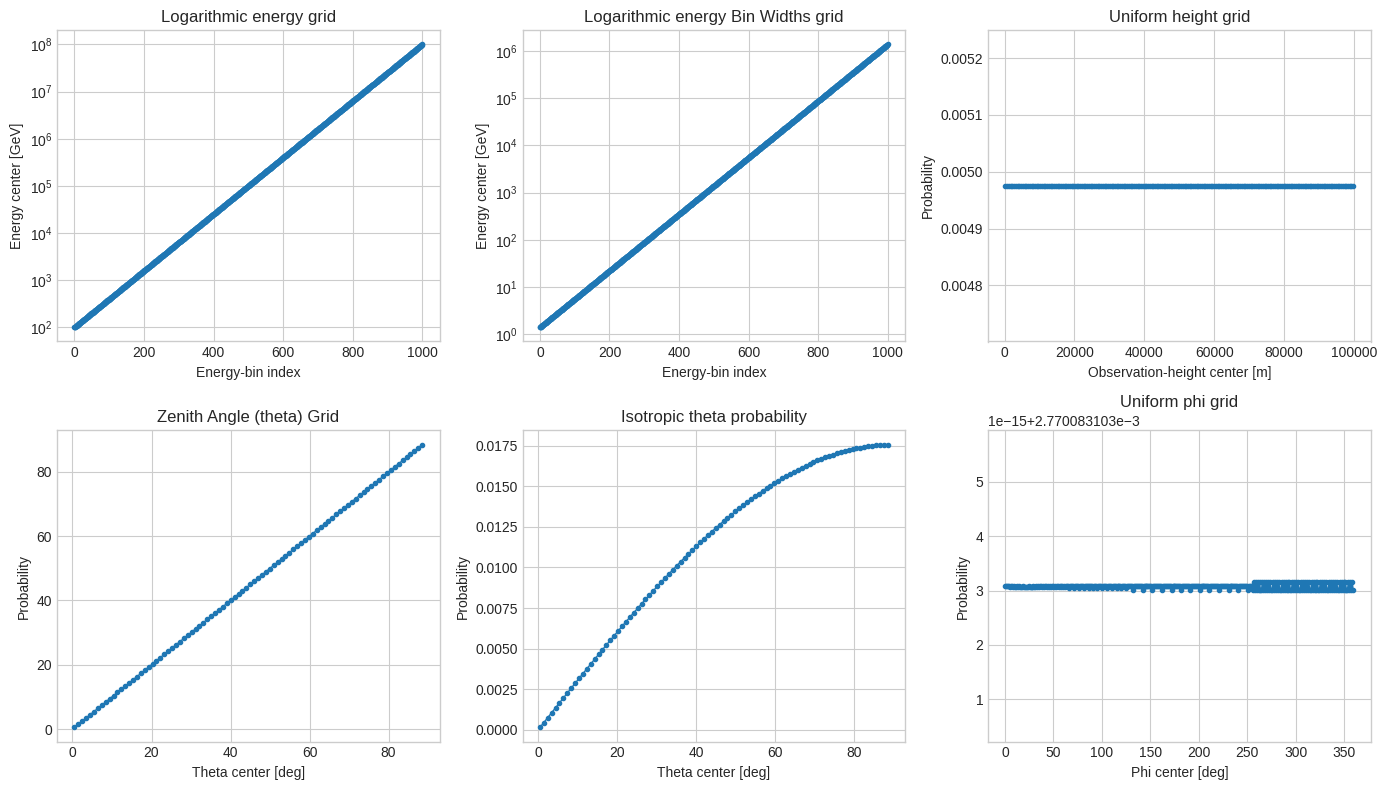

Subsection 3.1 test passed: grids are well formed.


In [6]:

energy_tables = build_energy_grid(CONFIG)
angle_tables = build_angular_tables(CONFIG)
height_tables = build_height_tables(CONFIG)

print("Grid summary")
print("-" * 72)
print(
    f"{'Energy':<10} bins={energy_tables['energy_centers_gev'].size:>4} | "
    f"min={energy_tables['energy_edges_gev'][0]:.3e} GeV | "
    f"max={energy_tables['energy_edges_gev'][-1]:.3e} GeV | spacing=logarithmic"
)
print(
    f"{'Theta':<10} bins={angle_tables['theta_centers_deg'].size:>4} | "
    f"min={angle_tables['theta_edges_deg'][0]:.3f} deg | "
    f"max={angle_tables['theta_edges_deg'][-1]:.3f} deg | spacing=linear in angle, isotropic in probability"
)
print(
    f"{'Phi':<10} bins={angle_tables['phi_centers_deg'].size:>4} | "
    f"min={angle_tables['phi_edges_deg'][0]:.3f} deg | "
    f"max={angle_tables['phi_edges_deg'][-1]:.3f} deg | spacing=linear"
)
print(
    f"{'Height':<10} bins={height_tables['h_centers_m'].size:>4} | "
    f"min={height_tables['h_edges_m'][0]:.1f} m | "
    f"max={height_tables['h_edges_m'][-1]:.1f} m | spacing=linear"
)
print(f"Solid angle covered by theta/phi grid: {angle_tables['solid_angle_sr']:.6f} sr")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].plot(np.arange(energy_tables['energy_centers_gev'].size), energy_tables['energy_centers_gev'], marker='.', linewidth=1)
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel('Energy-bin index')
axes[0, 0].set_ylabel('Energy center [GeV]')
axes[0, 0].set_title('Logarithmic energy grid')

axes[0, 1].plot(np.arange(energy_tables['energy_centers_gev'].size), energy_tables['energy_widths_gev'], marker='.', linewidth=1)
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Energy-bin index')
axes[0, 1].set_ylabel('Energy center [GeV]')
axes[0, 1].set_title('Logarithmic energy Bin Widths grid')

axes[0, 2].plot(height_tables['h_centers_m'], height_tables['h_probability'], marker='.', linewidth=1)
axes[0, 2].set_xlabel('Observation-height center [m]')
axes[0, 2].set_ylabel('Probability')
axes[0, 2].set_title('Uniform height grid')

axes[1, 0].plot(angle_tables['theta_centers_deg'], angle_tables['theta_centers_deg'], marker='.', linewidth=1)
axes[1, 0].set_xlabel('Theta center [deg]')
axes[1, 0].set_ylabel('Probability')
axes[1, 0].set_title('Zenith Angle (theta) Grid')

axes[1, 1].plot(angle_tables['theta_centers_deg'], angle_tables['theta_probability'], marker='.', linewidth=1)
axes[1, 1].set_xlabel('Theta center [deg]')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].set_title('Isotropic theta probability')

axes[1, 2].plot(angle_tables['phi_centers_deg'], angle_tables['phi_probability'], marker='.', linewidth=1)
axes[1, 2].set_xlabel('Phi center [deg]')
axes[1, 2].set_ylabel('Probability')
axes[1, 2].set_title('Uniform phi grid')


plt.tight_layout()
plt.show()# Subsection 3.1 smoke test: verify grid dictionaries and probability normalization.
assert set(energy_tables) == {"energy_edges_gev", "energy_centers_gev", "energy_widths_gev"}
assert energy_tables["energy_edges_gev"].size == CONFIG.energy_bins + 1
assert energy_tables["energy_centers_gev"].size == CONFIG.energy_bins
assert np.all(np.diff(energy_tables["energy_edges_gev"]) > 0)
assert np.isclose(angle_tables["theta_probability"].sum(), 1.0)
assert np.isclose(angle_tables["phi_probability"].sum(), 1.0)
assert np.isclose(height_tables["h_probability"].sum(), 1.0)
print("Subsection 3.1 test passed: grids are well formed.")

### 3.2. Flux Model Construction

This subsection selects and instantiates the CRFlux primary-flux model used to evaluate the physical cosmic-ray spectrum. The factory dictionary defined in the parameters section keeps model choice explicit and reproducible, while the smoke test checks that the selected object exposes a flux-evaluation method compatible with this workflow.

In [7]:
def create_crflux_model(model_name: str, factories: dict[str, Callable[[], Any]]) -> Any:
    """Instantiate a CRFlux model from the configured factory registry.

    Args:
        model_name: Name of the CRFlux model to instantiate.
        factories: Mapping from model names to zero-argument constructors.

    Returns:
        A CRFlux model object.
    """

    if not CRFLUX_AVAILABLE:
        raise ImportError("CRFlux is required to build this model in this notebook environment.")
    if model_name not in factories:
        raise ValueError(f"Unsupported model_name={model_name!r}. Supported models: {sorted(factories)}")
    return factories[model_name]()


primary_model = create_crflux_model(CONFIG.model_name, MODEL_FACTORIES)

CONFIG = replace(
    CONFIG,
    corsika_ids=np.asarray(primary_model.nucleus_ids, dtype=np.int32)
)
print(f"Using CRFlux model class: {type(primary_model).__name__}")



Using CRFlux model class: PolyGonato


In [8]:
# Subsection 3.2 smoke test: verify CRFlux model construction.
assert primary_model is not None
assert type(primary_model).__name__
assert hasattr(primary_model, "nucleus_flux") or hasattr(primary_model, "flux")
print(f"Subsection 3.2 test passed: using {type(primary_model).__name__}.")

Subsection 3.2 test passed: using PolyGonato.


### 3.3. Flux Evaluation

This subsection evaluates the differential primary flux for every configured species and energy-bin center, producing a table $\Phi_s(E)$ with shape `(species, energy)`. The values are later integrated over energy-bin widths to build the physical sampling weights. The additional plot below is useful for checking that each selected species follows the expected falling cosmic-ray spectrum across the configured energy range.

In [9]:
def evaluate_nucleus_flux(model: Any, corsika_id: int, energy_gev: float) -> float:
    """Evaluate one primary-species differential flux value.

    Args:
        model: CRFlux model instance.
        corsika_id: CORSIKA primary ID.
        energy_gev: Primary energy in GeV.

    Returns:
        Non-negative scalar differential flux in CRFlux model units.
    """

    if hasattr(model, "nucleus_flux"):
        value = model.nucleus_flux(corsika_id, energy_gev)
    elif hasattr(model, "flux"):
        value = model.flux(corsika_id, energy_gev)
    else:
        raise AttributeError("The selected CRFlux model exposes neither nucleus_flux nor flux.")

    array_value = np.asarray(value, dtype=np.float64).reshape(-1)
    scalar = float(array_value[0]) if array_value.size else 0.0
    return max(scalar, 0.0) if np.isfinite(scalar) else 0.0


def evaluate_flux_table(model: Any, config: CosmicRayModelConfig, energy_table: dict[str, np.ndarray]) -> np.ndarray:
    """Evaluate the species-energy flux table.

    Args:
        model: CRFlux model instance.
        config: Global model configuration.
        energy_table: Dictionary returned by `build_energy_grid`.

    Returns:
        Array with shape `(n_species, n_energy_bins)`.
    """

    centers = energy_table["energy_centers_gev"]
    flux = np.zeros((len(primary_model.nucleus_ids), centers.size), dtype=np.float64)
    for species_index, corsika_id in enumerate(primary_model.nucleus_ids):
        for energy_index, energy in enumerate(centers):
            flux[species_index, energy_index] = evaluate_nucleus_flux(model, corsika_id, float(energy))

    flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)
    flux[flux < 0.0] = 0.0
    if not np.any(flux > 0.0):
        raise ValueError("The evaluated flux table is empty. Check model, species, and energy range.")
    return flux


Flux table shape: (11, 1001)


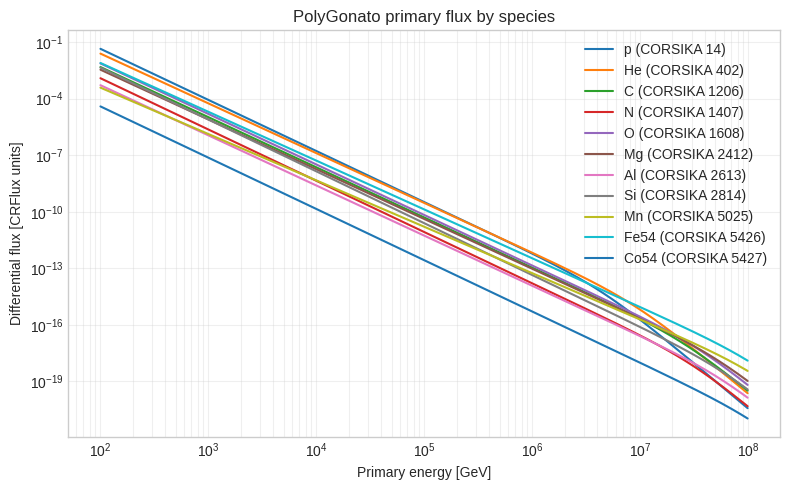


Model species catalog
------------------------------------
p    | CORSIKA ID   14 | positive bins=1001/1001 | min positive flux=3.782e-21 | max flux=4.394e-02
He   | CORSIKA ID  402 | positive bins=1001/1001 | min positive flux=2.351e-20 | max flux=2.448e-02
C    | CORSIKA ID 1206 | positive bins=1001/1001 | min positive flux=3.209e-20 | max flux=4.757e-03
N    | CORSIKA ID 1407 | positive bins=1001/1001 | min positive flux=4.785e-21 | max flux=1.210e-03
O    | CORSIKA ID 1608 | positive bins=1001/1001 | min positive flux=6.488e-20 | max flux=7.377e-03
Mg   | CORSIKA ID 2412 | positive bins=1001/1001 | min positive flux=1.052e-19 | max flux=3.433e-03
Al   | CORSIKA ID 2613 | positive bins=1001/1001 | min positive flux=1.359e-20 | max flux=5.161e-04
Si   | CORSIKA ID 2814 | positive bins=1001/1001 | min positive flux=3.733e-20 | max flux=4.392e-03
Mn   | CORSIKA ID 5025 | positive bins=1001/1001 | min positive flux=3.582e-19 | max flux=3.828e-04
Fe54 | CORSIKA ID 5426 | positive bins=1

In [10]:
# Subsection 3.3 diagnostic: plot species fluxes as a function of energy.

flux_table = evaluate_flux_table(primary_model, CONFIG, energy_tables)
print(f"Flux table shape: {flux_table.shape}")

energy_centers = energy_tables["energy_centers_gev"]
fig, ax = plt.subplots(figsize=(8, 5))
for species_index, corsika_id in enumerate(primary_model.nucleus_ids):
    species = PRIMARY_SPECIES[corsika_id]
    label = f"{species['mnemonic']} (CORSIKA {corsika_id})"
    ax.plot(energy_centers, flux_table[species_index], label=label, linewidth=1.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Primary energy [GeV]")
ax.set_ylabel("Differential flux [CRFlux units]")
ax.set_title(f"{CONFIG.model_name} primary flux by species")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
print("\nModel species catalog")
print("-" * 36)

for species_index, corsika_id in enumerate(primary_model.nucleus_ids):
    species = PRIMARY_SPECIES[corsika_id]
    values = flux_table[species_index]
    positive = values[values > 0]
    min_positive = positive.min() if positive.size else np.nan
    print(
        f"{species['mnemonic']:<4} | CORSIKA ID {corsika_id:>4} | "
        f"positive bins={positive.size:>4}/{values.size} | "
        f"min positive flux={min_positive:.3e} | max flux={values.max():.3e}"
    )
# Subsection 3.3 smoke test: verify flux-table shape and positivity.
assert flux_table.shape == (len(primary_model.nucleus_ids), CONFIG.energy_bins)
assert np.all(np.isfinite(flux_table))
assert np.all(flux_table >= 0.0)
assert np.any(flux_table > 0.0)
print("\nSubsection 3.3 test passed: flux table is finite and non-empty.")

### 3.4. Sampling-Table Construction

This subsection converts the evaluated flux table into normalized sampling tables. For each species-energy bin, the unnormalized weight is $w_{s,E} = \Phi_s(E)\,\Delta E$. These weights are normalized into $P(s,E) = w_{s,E}/\sum_{s,E} w_{s,E}$ and stored together with the marginal species and energy probabilities used by the next notebook.

In [11]:
def build_sampling_tables(flux: np.ndarray, energy_table: dict[str, np.ndarray]) -> dict[str, np.ndarray | float]:
    """Normalize fluxes into sampling weights.

    Args:
        flux: Species-energy differential flux table.
        energy_table: Dictionary returned by `build_energy_grid`.

    Returns:
        Integrated bin weights, normalized probabilities, CDF, and marginal distributions.
    """

    widths = energy_table["energy_widths_gev"]
    bin_weights = flux * widths[np.newaxis, :]
    total_weight = float(bin_weights.sum())
    if total_weight <= 0 or not np.isfinite(total_weight):
        raise ValueError("Integrated flux table is empty.")

    probability = bin_weights / total_weight
    flat_cdf = np.cumsum(probability.ravel())
    flat_cdf[-1] = 1.0
    return {
        "bin_weights": bin_weights,
        "species_energy_probability": probability,
        "species_energy_cdf": flat_cdf,
        "species_probability": probability.sum(axis=1),
        "energy_probability": probability.sum(axis=0),
        "total_energy_integrated_flux": total_weight,
    }


Sampling table diagnostics
Number of species              : 11
Number of energy bins          : 1001
Total energy-integrated flux   : 5.977659e+00
Probability normalization      : 1.000000000000
Species probability sum        : 1.000000000000
Energy probability sum         : 1.000000000000
CDF first value                : 1.021632e-02
CDF last value                 : 1.000000000000
Min probability                : 2.456417e-16
Max probability                : 1.021632e-02

Species marginal probabilities:
           p : 4.380062e-01
          He : 2.542467e-01
           C : 4.882706e-02
           N : 1.199503e-02
           O : 7.482607e-02
          Mg : 3.566578e-02
          Al : 5.297275e-03
          Si : 4.278946e-02
          Mn : 4.461140e-03
        Fe54 : 8.350195e-02
        Co54 : 3.833307e-04


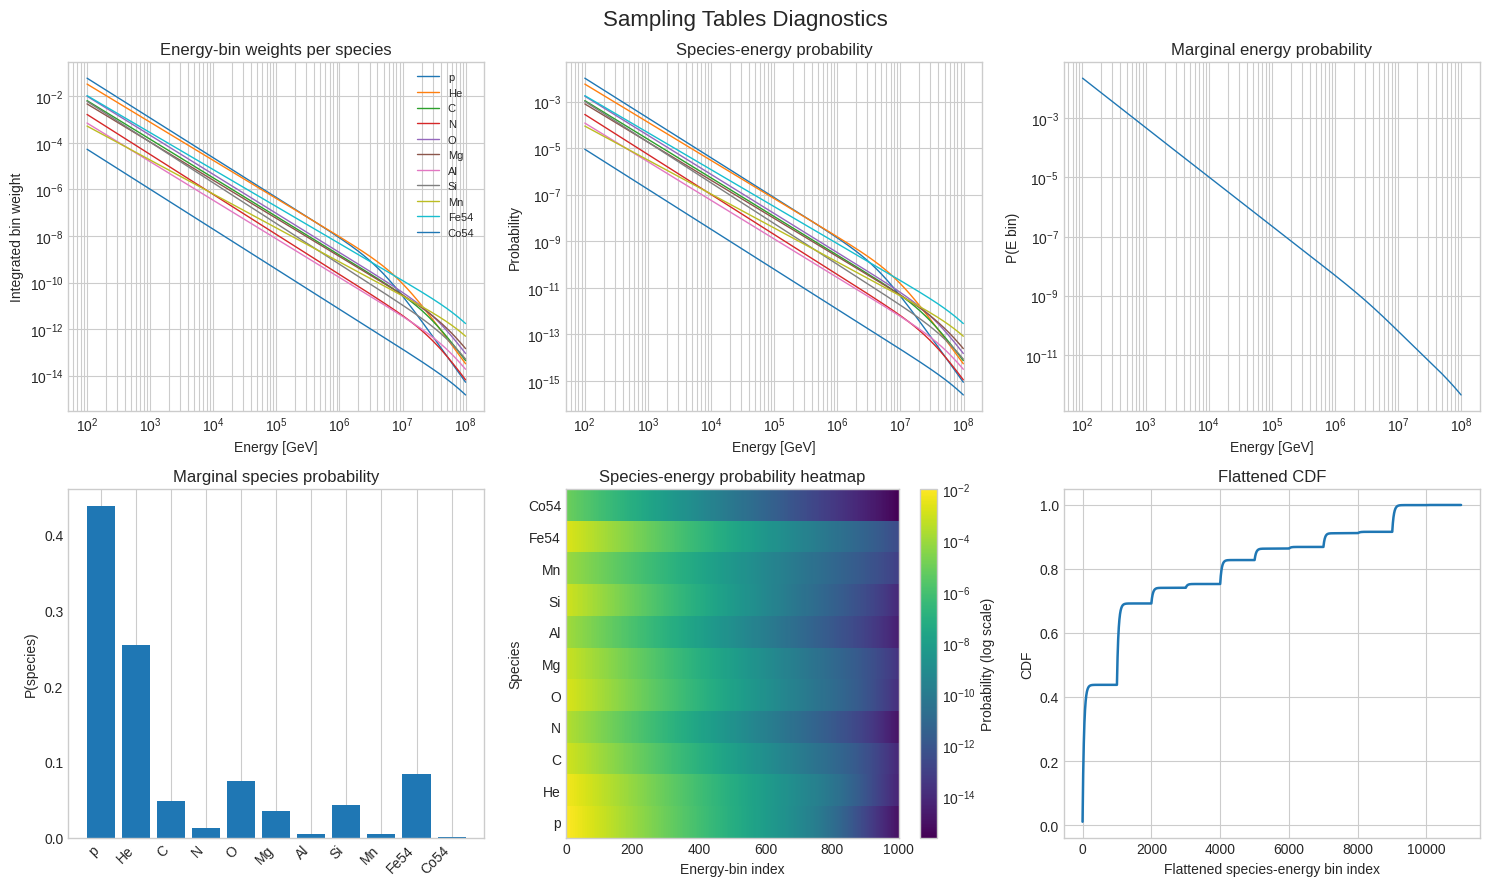


Subsection 3.4 test passed: sampling tables are normalized.


In [12]:
def plot_sampling_tables(
    sampling: dict[str, np.ndarray | float],
    energy_table: dict[str, np.ndarray],
    species_ids: np.ndarray | list[int] | None = None,
    species_names: dict[int, str] | None = None,
    figsize: tuple[float, float] = (15, 9),
    logx: bool = True,
    logy_flux: bool = True,
) -> None:
    """
    Plot and print diagnostics from build_sampling_tables output.

    Args:
        sampling:
            Dictionary returned by build_sampling_tables.
        energy_table:
            Dictionary returned by build_energy_grid.
        species_ids:
            Optional list/array of CORSIKA IDs, one per species.
        species_names:
            Optional mapping {corsika_id: name}.
        figsize:
            Figure size.
        logx:
            If True, use logarithmic x-axis for energy plots.
        logy_flux:
            If True, use logarithmic y-axis for bin weights.
    """

    bin_weights = sampling["bin_weights"]
    probability = sampling["species_energy_probability"]
    flat_cdf = sampling["species_energy_cdf"]
    species_probability = sampling["species_probability"]
    energy_probability = sampling["energy_probability"]
    total_flux = sampling["total_energy_integrated_flux"]

    energy_edges = energy_table["energy_edges_gev"]
    energy_centers = energy_table.get(
        "energy_centers_gev",
        np.sqrt(energy_edges[:-1] * energy_edges[1:])
    )

    n_species, n_energy = probability.shape

    if species_ids is None:
        species_ids = np.arange(n_species)

    species_ids = np.asarray(species_ids)

    labels = []
    for cid in species_ids:
        if species_names is not None and int(cid) in species_names:
            labels.append(species_names[int(cid)])
        else:
            labels.append(str(cid))

    print("=" * 80)
    print("Sampling table diagnostics")
    print("=" * 80)
    print(f"Number of species              : {n_species}")
    print(f"Number of energy bins          : {n_energy}")
    print(f"Total energy-integrated flux   : {total_flux:.6e}")
    print(f"Probability normalization      : {probability.sum():.12f}")
    print(f"Species probability sum        : {species_probability.sum():.12f}")
    print(f"Energy probability sum         : {energy_probability.sum():.12f}")
    print(f"CDF first value                : {flat_cdf[0]:.6e}")
    print(f"CDF last value                 : {flat_cdf[-1]:.12f}")
    print(f"Min probability                : {probability.min():.6e}")
    print(f"Max probability                : {probability.max():.6e}")

    print("\nSpecies marginal probabilities:")
    for label, p in zip(labels, species_probability):
        print(f"  {label:>10s} : {p:.6e}")

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    # ---------------------------------------------------------
    # 1. Bin weights per species
    # ---------------------------------------------------------
    ax = axes[0]
    for i, label in enumerate(labels):
        ax.plot(energy_centers, bin_weights[i],  lw=1.0, label=label)

    ax.set_xlabel("Energy [GeV]")
    ax.set_ylabel("Integrated bin weight")
    ax.set_title("Energy-bin weights per species")
    ax.grid(True, which="both")
    ax.legend(fontsize=8)

    if logx:
        ax.set_xscale("log")
    if logy_flux:
        ax.set_yscale("log")

    # ---------------------------------------------------------
    # 2. Species-energy probability per species
    # ---------------------------------------------------------
    ax = axes[1]
    for i, label in enumerate(labels):
        ax.plot(energy_centers, probability[i], lw=1.0, label=label)

    ax.set_xlabel("Energy [GeV]")
    ax.set_ylabel("Probability")
    ax.set_title("Species-energy probability")
    ax.grid(True, which="both")

    if logx:
        ax.set_xscale("log")
    ax.set_yscale("log")

    # ---------------------------------------------------------
    # 3. Energy marginal probability
    # ---------------------------------------------------------
    ax = axes[2]
    ax.plot(energy_centers, energy_probability, lw=1.0)

    ax.set_xlabel("Energy [GeV]")
    ax.set_ylabel("P(E bin)")
    ax.set_title("Marginal energy probability")
    ax.grid(True, which="both")

    if logx:
        ax.set_xscale("log")
    ax.set_yscale("log")

    # ---------------------------------------------------------
    # 4. Species marginal probability
    # ---------------------------------------------------------
    ax = axes[3]
    x = np.arange(n_species)
    ax.bar(x, species_probability)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("P(species)")
    ax.set_title("Marginal species probability")
    ax.grid(axis="y")

    # ---------------------------------------------------------
    # 5. 2D probability table
    # ---------------------------------------------------------
    from matplotlib.colors import LogNorm

    ax = axes[4]
    positive_probability = probability[probability > 0]
    if positive_probability.size == 0:
        ax.text(0.5, 0.5, "No positive probabilities", ha="center", va="center")
        ax.set_axis_off()
    else:
        x_edges = np.arange(n_energy + 1)
        y_edges = np.arange(n_species + 1)
        im = ax.pcolormesh(
            x_edges,
            y_edges,
            np.ma.masked_less_equal(probability, 0.0),
            cmap="viridis",
            norm=LogNorm(vmin=positive_probability.min(), vmax=positive_probability.max()),
            shading="flat",
        )

        ax.set_yticks(np.arange(n_species) + 0.5)
        ax.set_yticklabels(labels)
        ax.set_xlabel("Energy-bin index")
        ax.set_ylabel("Species")
        ax.set_title("Species-energy probability heatmap")
        fig.colorbar(im, ax=ax, label="Probability (log scale)")

    # ---------------------------------------------------------
    # 6. Flattened CDF
    # ---------------------------------------------------------
    ax = axes[5]
    ax.plot(np.arange(flat_cdf.size), flat_cdf, lw=1.8)

    ax.set_xlabel("Flattened species-energy bin index")
    ax.set_ylabel("CDF")
    ax.set_title("Flattened CDF")
    ax.grid(True)

    fig.suptitle("Sampling Tables Diagnostics", fontsize=16)
    fig.tight_layout()
    plt.show()
    
sampling_tables = build_sampling_tables(flux_table, energy_tables)
species_mnemonics = {
    int(corsika_id): str(PRIMARY_SPECIES[int(corsika_id)]["mnemonic"])
    for corsika_id in primary_model.nucleus_ids
}
plot_sampling_tables(
    sampling=sampling_tables,
    energy_table=energy_tables,
    species_ids=primary_model.nucleus_ids,
    species_names=species_mnemonics,
)

# Subsection 3.4 smoke test: verify sampling-table normalization.
assert sampling_tables["species_energy_probability"].shape == flux_table.shape
assert np.isclose(sampling_tables["species_energy_probability"].sum(), 1.0)
assert np.isclose(sampling_tables["species_energy_cdf"][-1], 1.0)
assert np.isclose(sampling_tables["species_probability"].sum(), 1.0)
assert np.isclose(sampling_tables["energy_probability"].sum(), 1.0)
print("\nSubsection 3.4 test passed: sampling tables are normalized.")


In [13]:
# Section 3 smoke test: verify that all helper functions are defined.
for function_name in [
    "build_energy_grid",
    "build_angular_tables",
    "build_height_tables",
    "create_crflux_model",
    "evaluate_nucleus_flux",
    "evaluate_flux_table",
    "build_sampling_tables",
]:
    assert function_name in globals(), f"Missing helper function: {function_name}"
print("Section 3 test passed: helper-function namespace is complete.")

Section 3 test passed: helper-function namespace is complete.


## 4. HDF5 Storage

This section writes the complete factorized model to HDF5, including grids, probabilities, cumulative distributions, species metadata, and provenance attributes.

In [14]:
def corsika_id_to_nucleus(corsika_id: int) -> tuple[int, int]:
    """Convert a CORSIKA primary ID to nuclear charge and mass.

    Args:
        corsika_id: CORSIKA primary ID; nuclei use `100*A + Z`, while proton is legacy ID 14.

    Returns:
        `(Z, A)` as integers.
    """

    if int(corsika_id) == 14:
        return 1, 1
    return int(corsika_id) % 100, int(corsika_id) // 100


def save_model(flux_table: np.ndarray, output_path: Path = CONFIG.output_path) -> None:
    """Write the complete factorized model to HDF5.

    Args:
        output_path: Destination HDF5 path.

    Returns:
        None. The file is overwritten if it already exists.
    """

    z_values, a_values, pdg_values, mnemonics, species_names = [], [], [], [], []
    for corsika_id in CONFIG.corsika_ids:
        z, a = corsika_id_to_nucleus(corsika_id)
        species = PRIMARY_SPECIES[corsika_id]
        z_values.append(z)
        a_values.append(a)
        pdg_values.append(int(species["pdg"]))
        mnemonics.append(str(species["mnemonic"]))
        species_names.append(str(species["name"]))

    with h5py.File(output_path, "w") as h5:
        h5.attrs["description"] = "Primary cosmic-ray model for CORSIKA with species, energy, angle, and observation-height grids"
        h5.attrs["model_name"] = CONFIG.model_name
        h5.attrs["model_variant"] = "" if CONFIG.model_variant is None else CONFIG.model_variant
        h5.attrs["factorization"] = "P(species,energy) * P(theta) * P(phi) * P(h)"
        h5.attrs["height_note"] = "CRFlux is height-independent; probabilities are duplicated uniformly over h bins."
        h5.attrs["particle_id_convention"] = "CORSIKA IDs; nuclei use 100*A + Z; proton legacy ID is 14"

        energy_group = h5.create_group("energy")
        energy_group.create_dataset("edges_gev", data=energy_tables["energy_edges_gev"])
        energy_group.create_dataset("centers_gev", data=energy_tables["energy_centers_gev"])
        energy_group.create_dataset("widths_gev", data=energy_tables["energy_widths_gev"])

        theta_group = h5.create_group("angle/theta")
        theta_group.create_dataset("edges_deg", data=angle_tables["theta_edges_deg"])
        theta_group.create_dataset("centers_deg", data=angle_tables["theta_centers_deg"])
        theta_group.create_dataset("probability", data=angle_tables["theta_probability"])
        theta_group.create_dataset("cdf", data=angle_tables["theta_cdf"])

        phi_group = h5.create_group("angle/phi")
        phi_group.create_dataset("edges_deg", data=angle_tables["phi_edges_deg"])
        phi_group.create_dataset("centers_deg", data=angle_tables["phi_centers_deg"])
        phi_group.create_dataset("probability", data=angle_tables["phi_probability"])
        phi_group.create_dataset("cdf", data=angle_tables["phi_cdf"])
        h5["angle"].attrs["solid_angle_sr"] = angle_tables["solid_angle_sr"]

        height_group = h5.create_group("height")
        height_group.create_dataset("edges_m", data=height_tables["h_edges_m"])
        height_group.create_dataset("centers_m", data=height_tables["h_centers_m"])
        height_group.create_dataset("probability", data=height_tables["h_probability"])
        height_group.create_dataset("cdf", data=height_tables["h_cdf"])

        species_group = h5.create_group("species")
        species_group.create_dataset("corsika_ids", data=np.asarray(primary_model.nucleus_ids, dtype=np.int32))
        species_group.create_dataset("atomic_number_Z", data=np.asarray(z_values, dtype=np.int32))
        species_group.create_dataset("mass_number_A", data=np.asarray(a_values, dtype=np.int32))
        species_group.create_dataset("corsika8_pdg", data=np.asarray(pdg_values, dtype=np.int32))
        string_dtype = h5py.string_dtype(encoding="utf-8")
        species_group.create_dataset("mnemonic", data=np.asarray(mnemonics, dtype=object), dtype=string_dtype)
        species_group.create_dataset("name", data=np.asarray(species_names, dtype=object), dtype=string_dtype)
        species_group.create_dataset("probability", data=sampling_tables["species_probability"])

        model_group = h5.create_group("model")
        model_group.create_dataset("differential_flux", data=flux_table, compression="gzip", compression_opts=4)
        model_group.create_dataset("bin_weights", data=sampling_tables["bin_weights"], compression="gzip", compression_opts=4)
        model_group.create_dataset("species_energy_probability", data=sampling_tables["species_energy_probability"], compression="gzip", compression_opts=4)
        model_group.create_dataset("species_energy_cdf", data=sampling_tables["species_energy_cdf"], compression="gzip", compression_opts=4)
        model_group.create_dataset("energy_probability", data=sampling_tables["energy_probability"], compression="gzip", compression_opts=4)
        model_group.create_dataset("theta_probability", data=angle_tables["theta_probability"])
        model_group.create_dataset("phi_probability", data=angle_tables["phi_probability"])
        model_group.create_dataset("height_probability", data=height_tables["h_probability"])
        model_group.create_dataset("total_energy_integrated_flux", data=sampling_tables["total_energy_integrated_flux"])
        model_group.create_dataset("cone_integrated_flux", data=sampling_tables["total_energy_integrated_flux"] * angle_tables["solid_angle_sr"])


save_model(flux_table = flux_table, output_path = CONFIG.output_path)
print(f"Saved HDF5 model to: {CONFIG.output_path}")
print(f"File size: {Path(CONFIG.output_path).stat().st_size / 1024:.1f} KiB")

Saved HDF5 model to: /mnt/v/output/data/corsika/generator/run_test/cosmic_ray_model_test.h5
File size: 394.8 KiB


In [15]:
# Section 4 smoke test: verify that the HDF5 file was written with expected groups.
assert CONFIG.output_path.exists()
with h5py.File(CONFIG.output_path, "r") as h5:
    for group_name in ["energy", "angle", "height", "species", "model"]:
        assert group_name in h5, f"Missing HDF5 group: {group_name}"
    assert h5["energy/edges_gev"].shape[0] == CONFIG.energy_bins + 1
    assert h5["height/centers_m"].shape[0] == CONFIG.h_bins
print("Section 4 test passed: HDF5 file contains expected groups and datasets.")

Section 4 test passed: HDF5 file contains expected groups and datasets.


## 5. File Reading and Verification

This section reloads the HDF5 model, prints the metadata stored with the file, checks probability normalizations, and visualizes the main stored distributions. The diagnostic plot uses six axes to compare species-summed differential flux, species-summed integrated bin weights, the energy marginal probability, the species marginal probability, and the factorized angular probability for representative primary-energy bins.

HDF5 metadata
------------------------------------------------------------------------
                 description: Primary cosmic-ray model for CORSIKA with species, energy, angle, and observation-height grids
               factorization: P(species,energy) * P(theta) * P(phi) * P(h)
                 height_note: CRFlux is height-independent; probabilities are duplicated uniformly over h bins.
                  model_name: PolyGonato
               model_variant: 
      particle_id_convention: CORSIKA IDs; nuclei use 100*A + Z; proton legacy ID is 14

Stored array summary
------------------------------------------------------------------------
Energy bins:              1001 (1.000e+02 to 1.000e+08 GeV)
Theta bins:               90 (0.494 to 88.506 deg centers)
Height bins:              201 (248.8 to 99751.2 m centers)
Flux table shape:         (11, 1001)
Species-energy shape:     (11, 1001)

Probability normalization checks
------------------------------------------------------------

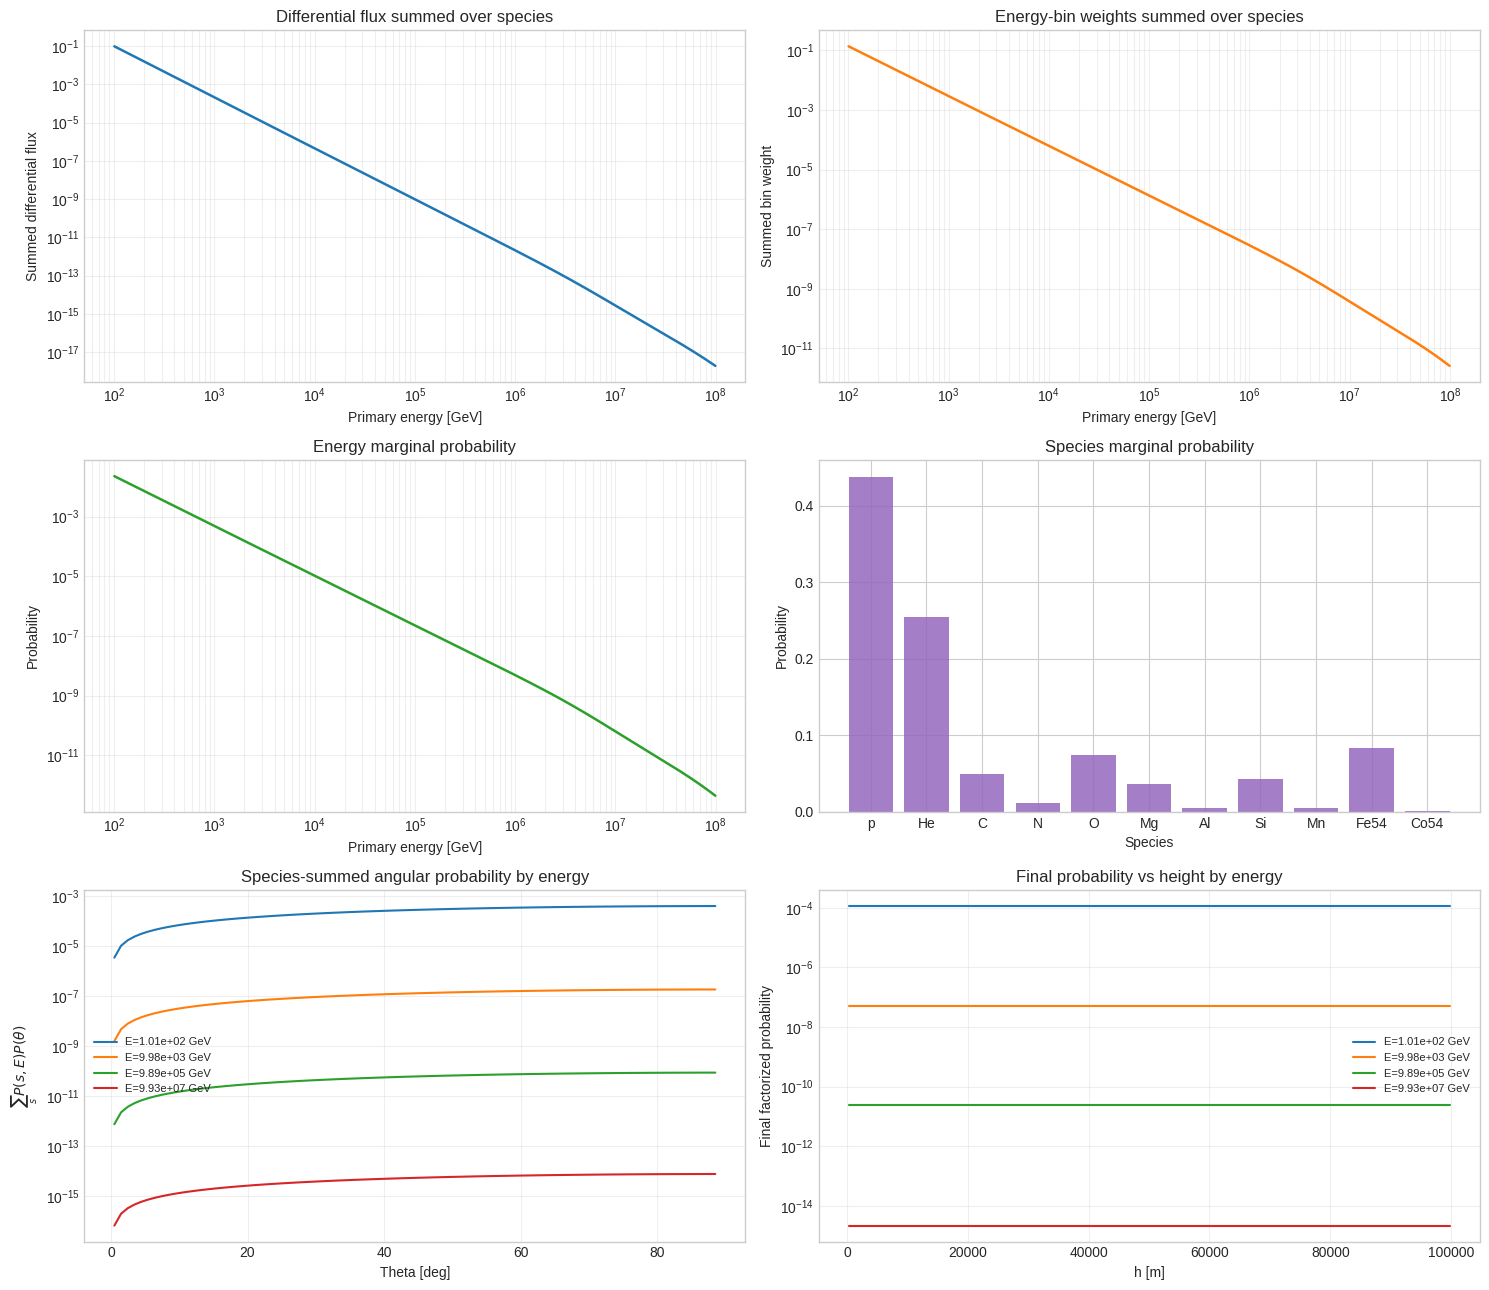

In [16]:
with h5py.File(CONFIG.output_path, "r") as h5:
    print("HDF5 metadata")
    print("-" * 72)
    for key, value in h5.attrs.items():
        print(f"{key:>28}: {value}")

    loaded_energy_centers = h5["energy/centers_gev"][:]
    loaded_energy_edges = h5["energy/edges_gev"][:]
    loaded_theta_centers = h5["angle/theta/centers_deg"][:]
    loaded_height_centers = h5["height/centers_m"][:]
    loaded_flux = h5["model/differential_flux"][:]
    loaded_bin_weights = h5["model/bin_weights"][:]
    loaded_species_energy_probability = h5["model/species_energy_probability"][:]
    loaded_energy_probability = h5["model/energy_probability"][:]
    loaded_theta_probability = h5["angle/theta/probability"][:]
    loaded_phi_probability = h5["angle/phi/probability"][:]
    loaded_height_probability = h5["height/probability"][:]
    loaded_species_probability = h5["species/probability"][:]
    loaded_corsika_ids = h5["species/corsika_ids"][:].astype(int)
    loaded_species_mnemonics = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in h5["species/mnemonic"][:]]
    loaded_species_names = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in h5["species/name"][:]]

    checks = {
        "species_energy": loaded_species_energy_probability.sum(),
        "energy": loaded_energy_probability.sum(),
        "theta": loaded_theta_probability.sum(),
        "phi": loaded_phi_probability.sum(),
        "height": loaded_height_probability.sum(),
        "species": loaded_species_probability.sum(),
    }

print("\nStored array summary")
print("-" * 72)
print(f"Energy bins:              {loaded_energy_centers.size} ({loaded_energy_edges[0]:.3e} to {loaded_energy_edges[-1]:.3e} GeV)")
print(f"Theta bins:               {loaded_theta_centers.size} ({loaded_theta_centers.min():.3f} to {loaded_theta_centers.max():.3f} deg centers)")
print(f"Height bins:              {loaded_height_centers.size} ({loaded_height_centers.min():.1f} to {loaded_height_centers.max():.1f} m centers)")
print(f"Flux table shape:         {loaded_flux.shape}")
print(f"Species-energy shape:     {loaded_species_energy_probability.shape}")
print("\nProbability normalization checks")
print("-" * 72)
for name, value in checks.items():
    print(f"{name:>18}: {value:.12f}")
assert all(np.isclose(value, 1.0) for value in checks.values())

print("\nStored species metadata")
print("-" * 72)
for corsika_id, mnemonic, name, probability in zip(
    loaded_corsika_ids,
    loaded_species_mnemonics,
    loaded_species_names,
    loaded_species_probability,
):
    print(f"CORSIKA ID {corsika_id:>4}: {mnemonic:<3} | {name:<7} | P(species)={probability:.6e}")

species_summed_flux = loaded_flux.sum(axis=0)
species_summed_bin_weights = loaded_bin_weights.sum(axis=0)
energy_indices = np.unique(np.linspace(0, loaded_energy_centers.size - 1, 4, dtype=int))

fig, axes = plt.subplots(3, 2, figsize=(15, 13))

axes[0, 0].plot(loaded_energy_centers, species_summed_flux, color="tab:blue", linewidth=1.8)
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Primary energy [GeV]")
axes[0, 0].set_ylabel("Summed differential flux")
axes[0, 0].set_title("Differential flux summed over species")
axes[0, 0].grid(True, which="both", alpha=0.3)

axes[0, 1].plot(loaded_energy_centers, species_summed_bin_weights, color="tab:orange", linewidth=1.8)
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("Primary energy [GeV]")
axes[0, 1].set_ylabel("Summed bin weight")
axes[0, 1].set_title("Energy-bin weights summed over species")
axes[0, 1].grid(True, which="both", alpha=0.3)

axes[1, 0].plot(loaded_energy_centers, loaded_energy_probability, color="tab:green", linewidth=1.8)
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Primary energy [GeV]")
axes[1, 0].set_ylabel("Probability")
axes[1, 0].set_title("Energy marginal probability")
axes[1, 0].grid(True, which="both", alpha=0.3)

axes[1, 1].bar(loaded_species_mnemonics, loaded_species_probability, color="tab:purple", alpha=0.85)
axes[1, 1].set_xlabel("Species")
axes[1, 1].set_ylabel("Probability")
axes[1, 1].set_title("Species marginal probability")

for energy_index in energy_indices:
    energy_label = f"E={loaded_energy_centers[energy_index]:.2e} GeV"
    angular_probability = loaded_species_energy_probability[:, energy_index].sum() * loaded_theta_probability
    axes[2, 0].plot(loaded_theta_centers, angular_probability, linewidth=1.5, label=energy_label)
axes[2, 0].set_xlabel("Theta [deg]")
axes[2, 0].set_ylabel(r"$\sum_s P(s,E)P(\theta)$")
axes[2, 0].set_yscale("log")
axes[2, 0].set_title("Species-summed angular probability by energy")
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend(fontsize=8)

for energy_index in energy_indices:
    energy_label = f"E={loaded_energy_centers[energy_index]:.2e} GeV"
    final_probability = (
        loaded_species_energy_probability[:, energy_index].sum()
        * loaded_theta_probability.sum()
        * loaded_phi_probability.sum()
        * loaded_height_probability
    )
    axes[2, 1].plot(loaded_height_centers, final_probability, linewidth=1.5, label=energy_label)
axes[2, 1].set_xlabel("h [m]")
axes[2, 1].set_ylabel("Final factorized probability")
axes[2, 1].set_yscale("log")
axes[2, 1].set_title("Final probability vs height by energy")
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [17]:
# Section 5 smoke test: verify reloaded probabilities, metadata, and diagnostic axes.
assert all(np.isclose(value, 1.0) for value in checks.values())
assert axes.shape == (3, 2)
assert loaded_flux.shape == (len(loaded_corsika_ids), loaded_energy_centers.size)
assert len(loaded_species_mnemonics) == len(loaded_corsika_ids)
assert np.all(species_summed_flux >= 0.0)
assert np.all(species_summed_bin_weights >= 0.0)
print("Section 5 test passed: file reload, metadata, probability checks, and 3x2 diagnostics succeeded.")


Section 5 test passed: file reload, metadata, probability checks, and 3x2 diagnostics succeeded.
